In [1]:
import pandas as pd
import numpy as np

# Load event-level dataset
df = pd.read_csv("../data/processed/olympic_1896_2024_extended.csv")



In [2]:
# Keep only Summer Olympics
summer_years = [
1896,1900,1904,1908,1912,
1920,1924,1928,1932,1936,
1948,1952,1956,1960,1964,
1968,1972,1976,1980,1984,
1988,1992,1996,2000,2004,
2008,2012,2016,2020,2024
]

df = df[df["Year"].isin(summer_years)]

# Keep only medal-winning rows
df = df[df["Medal"].notna()]
# Basic sanity check
print("Shape:", df.shape)

df.head()


Shape: (41117, 7)


,Name,Sex,NOC,Year,Sport,Event,Medal
3,Edgar Lindenau Aabye,M,DEN,1900,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,Arvo Ossian Aaltonen,M,FIN,1920,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,Arvo Ossian Aaltonen,M,FIN,1920,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
41,Paavo Johannes Aaltonen,M,FIN,1948,Gymnastics,Gymnastics Men's Individual All-Around,Bronze
42,Paavo Johannes Aaltonen,M,FIN,1948,Gymnastics,Gymnastics Men's Team All-Around,Gold


In [3]:
# ===============================
# FIX: Count medal EVENTS not athletes
# ===============================

# Remove duplicate athletes from same medal event
event_medals = df.drop_duplicates(
    subset=["Year", "Sport", "Event", "NOC", "Medal"]
)

# Now aggregate medals correctly
sport_year_country = (
    event_medals
    .groupby(["Year", "Sport", "NOC"])
    .size()
    .reset_index(name="Total_Medals")
)

sport_year_country.head()

,Year,Sport,NOC,Total_Medals
0,1896,Athletics,AUS,2
1,1896,Athletics,FRA,2
2,1896,Athletics,GBR,2
3,1896,Athletics,GER,1
4,1896,Athletics,GRE,9


In [4]:
# Use modern era only (2000+)
# Reason: Pre-2000 data has structural differences in sport composition,
# fewer countries competing, and incomplete GDP data. 2000+ gives cleaner signal.
sport_year_country = sport_year_country[
    sport_year_country["Year"] >= 2000
]

print("Filtered shape:", sport_year_country.shape)
print("Years included:", sorted(sport_year_country["Year"].unique()))

Filtered shape: (2964, 4)
Years included: [2000, 2004, 2008, 2012, 2016, 2020, 2024]


In [5]:
# ============================
# GLOBAL SPORT POWER INDEX
# ============================

global_sport_power = (
    sport_year_country
    .groupby(["Sport","NOC"])["Total_Medals"]
    .sum()
    .reset_index()
)

# rank countries inside each sport
global_sport_power["Rank"] = (
    global_sport_power
    .groupby("Sport")["Total_Medals"]
    .rank(method="dense", ascending=False)
)

global_sport_power.head(20)

,Sport,NOC,Total_Medals,Rank
0,3x3 Basketball,ESP,1,2.0
1,3x3 Basketball,FRA,1,2.0
2,3x3 Basketball,GER,1,2.0
3,3x3 Basketball,HKG,1,2.0
4,3x3 Basketball,LAT,1,2.0
5,3x3 Basketball,LTU,1,2.0
6,3x3 Basketball,NED,1,2.0
7,3x3 Basketball,URS,2,1.0
8,3x3 Basketball,USA,2,1.0
9,3x3 Basketball,YUG,1,2.0


In [6]:
# ==========================================
# INDIA GLOBAL SPORT POSITION
# ==========================================

india_global = global_sport_power[
    global_sport_power["NOC"] == "IND"
].copy()

india_global = india_global.sort_values("Total_Medals", ascending=False)

print("\n--- India Global Sport Standing ---\n")
print(india_global.to_string(index=False))


--- India Global Sport Standing ---

        Sport NOC  Total_Medals  Rank
     Shooting IND             7   9.0
    Wrestling IND             7  13.0
    Badminton IND             3   7.0
       Boxing IND             3  16.0
    Athletics IND             2  26.0
       Hockey IND             2   5.0
Weightlifting IND             2  13.0


In [7]:
# ==========================================
# GAP TO GLOBAL LEADER
# ==========================================

leaders = (
    global_sport_power
    .sort_values(["Sport","Total_Medals"], ascending=[True, False])
    .groupby("Sport")
    .first()
    .reset_index()
)

leaders = leaders[["Sport","Total_Medals"]]
leaders.columns = ["Sport","Leader_Medals"]

india_vs_world = india_global.merge(
    leaders,
    on="Sport",
    how="left"
)

india_vs_world["Gap_to_Leader"] = (
    india_vs_world["Leader_Medals"] -
    india_vs_world["Total_Medals"]
)

india_vs_world = india_vs_world.sort_values("Gap_to_Leader")

print("\n--- India vs Global Leader ---\n")
print(india_vs_world.to_string(index=False))


--- India vs Global Leader ---

        Sport NOC  Total_Medals  Rank  Leader_Medals  Gap_to_Leader
       Hockey IND             2   5.0             11              9
    Badminton IND             3   7.0             37             34
       Boxing IND             3  16.0             39             36
Weightlifting IND             2  13.0             43             41
     Shooting IND             7   9.0             49             42
    Wrestling IND             7  13.0             50             43
    Athletics IND             2  26.0            184            182


In [8]:
# ==========================================
# COMPETITIVE SPORTS (TOP 10 GAP)
# ==========================================

competitive_sports = india_vs_world.sort_values("Gap_to_Leader").head(10)

print("\n--- India's Most Competitive Olympic Sports ---\n")
print(competitive_sports[
    ["Sport","Total_Medals","Leader_Medals","Gap_to_Leader"]
].to_string(index=False))


--- India's Most Competitive Olympic Sports ---

        Sport  Total_Medals  Leader_Medals  Gap_to_Leader
       Hockey             2             11              9
    Badminton             3             37             34
       Boxing             3             39             36
Weightlifting             2             43             41
     Shooting             7             49             42
    Wrestling             7             50             43
    Athletics             2            184            182


In [9]:
# ==========================================
# TOP 5 COUNTRIES PER SPORT
# ==========================================

top5_sports = global_sport_power[
    global_sport_power["Rank"] <= 5
]

print("\n--- Top 5 Countries per Sport ---\n")
print(top5_sports.head(25).to_string(index=False))


--- Top 5 Countries per Sport ---

              Sport NOC  Total_Medals  Rank
     3x3 Basketball ESP             1   2.0
     3x3 Basketball FRA             1   2.0
     3x3 Basketball GER             1   2.0
     3x3 Basketball HKG             1   2.0
     3x3 Basketball LAT             1   2.0
     3x3 Basketball LTU             1   2.0
     3x3 Basketball NED             1   2.0
     3x3 Basketball URS             2   1.0
     3x3 Basketball USA             2   1.0
     3x3 Basketball YUG             1   2.0
            Archery CHN             7   2.0
            Archery FRA             4   5.0
            Archery ITA             6   3.0
            Archery JPN             5   4.0
            Archery KOR            34   1.0
            Archery MEX             4   5.0
            Archery TPE             4   5.0
            Archery USA             7   2.0
Artistic Gymnastics BRA             6   4.0
Artistic Gymnastics CHN             9   2.0
Artistic Gymnastics GBR             4   

In [10]:
# =========================================
# TOTAL MEDALS PER SPORT
# =========================================

sport_total_medals = (
    sport_year_country
    .groupby("Sport")["Total_Medals"]
    .sum()
    .reset_index()
)

sport_total_medals.columns = ["Sport","Total_Sport_Medals"]

print(sport_total_medals.head().to_string(index=False))

              Sport  Total_Sport_Medals
     3x3 Basketball                  12
            Archery                  90
Artistic Gymnastics                  86
  Artistic Swimming                   9
          Athletics                 985


In [11]:
# =========================================
# COUNTRIES WINNING MEDALS PER SPORT
# =========================================

sport_country_count = (
    sport_year_country
    .groupby("Sport")["NOC"]
    .nunique()
    .reset_index()
)

sport_country_count.columns = ["Sport","Countries_With_Medals"]

print(sport_country_count.head().to_string(index=False))

              Sport  Countries_With_Medals
     3x3 Basketball                     10
            Archery                     17
Artistic Gymnastics                     25
  Artistic Swimming                      6
          Athletics                     86


In [12]:
# =========================================
# BUILD COMPETITIVE PRESSURE TABLE
# =========================================

sport_competition = sport_total_medals.merge(
    sport_country_count,
    on="Sport"
)

print(sport_competition.head().to_string(index=False))

              Sport  Total_Sport_Medals  Countries_With_Medals
     3x3 Basketball                  12                     10
            Archery                  90                     17
Artistic Gymnastics                  86                     25
  Artistic Swimming                   9                      6
          Athletics                 985                     86


In [13]:
# =========================================
# COMPETITIVE PRESSURE INDEX
# =========================================

sport_competition["Competitive_Pressure_Index"] = (
    sport_competition["Countries_With_Medals"] /
    sport_competition["Total_Sport_Medals"]
)

sport_competition = sport_competition.sort_values(
    "Competitive_Pressure_Index",
    ascending=False
)

print(sport_competition.head(15).to_string(index=False))

                Sport  Total_Sport_Medals  Countries_With_Medals  Competitive_Pressure_Index
             Breaking                   6                      6                    1.000000
       3x3 Basketball                  12                     10                    0.833333
    Baseball/Softball                   6                      4                    0.666667
Cycling BMX Freestyle                  12                      8                    0.666667
    Artistic Swimming                   9                      6                    0.666667
               Karate                  32                     19                    0.593750
Trampoline Gymnastics                  12                      7                    0.583333
Cycling Mountain Bike                  12                      7                    0.583333
    Marathon Swimming                  12                      7                    0.583333
                 Golf                  18                     10      

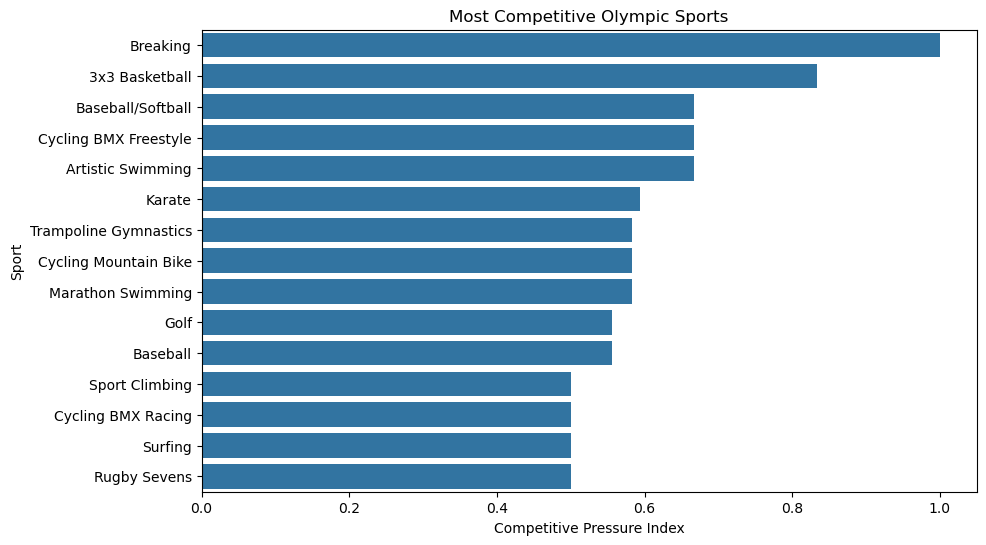

In [14]:
# =========================================
# MOST COMPETITIVE SPORTS
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns

top_competitive = sport_competition.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_competitive,
    x="Competitive_Pressure_Index",
    y="Sport"
)

plt.title("Most Competitive Olympic Sports")
plt.xlabel("Competitive Pressure Index")
plt.ylabel("Sport")

plt.show()

In [15]:
# =========================================
# INDIA IN GLOBAL COMPETITIVE CONTEXT
# =========================================

india_competitive_context = india_vs_world.merge(
    sport_competition[["Sport","Competitive_Pressure_Index"]],
    on="Sport",
    how="left"
)

print(india_competitive_context.to_string(index=False))

        Sport NOC  Total_Medals  Rank  Leader_Medals  Gap_to_Leader  Competitive_Pressure_Index
       Hockey IND             2   5.0             11              9                    0.238095
    Badminton IND             3   7.0             37             34                    0.144231
       Boxing IND             3  16.0             39             36                    0.165698
Weightlifting IND             2  13.0             43             41                    0.175084
     Shooting IND             7   9.0             49             42                    0.171254
    Wrestling IND             7  13.0             50             43                    0.117137
    Athletics IND             2  26.0            184            182                    0.087310


In [16]:
# =========================================
# CLOSENESS SCORE
# =========================================

india_competitive_context["Closeness_Score"] = (
    india_competitive_context["Total_Medals"] /
    india_competitive_context["Leader_Medals"]
)

india_competitive_context = india_competitive_context.sort_values(
    "Closeness_Score",
    ascending=False
)

print(india_competitive_context.to_string(index=False))

        Sport NOC  Total_Medals  Rank  Leader_Medals  Gap_to_Leader  Competitive_Pressure_Index  Closeness_Score
       Hockey IND             2   5.0             11              9                    0.238095         0.181818
     Shooting IND             7   9.0             49             42                    0.171254         0.142857
    Wrestling IND             7  13.0             50             43                    0.117137         0.140000
    Badminton IND             3   7.0             37             34                    0.144231         0.081081
       Boxing IND             3  16.0             39             36                    0.165698         0.076923
Weightlifting IND             2  13.0             43             41                    0.175084         0.046512
    Athletics IND             2  26.0            184            182                    0.087310         0.010870


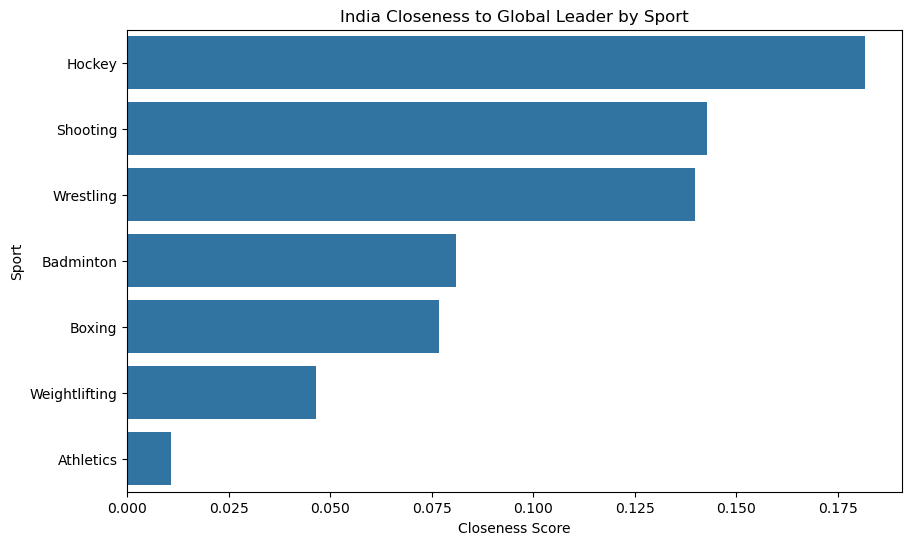

In [17]:
# =========================================
# CLOSENESS VISUALIZATION
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=india_competitive_context,
    x="Closeness_Score",
    y="Sport"
)

plt.title("India Closeness to Global Leader by Sport")
plt.xlabel("Closeness Score")
plt.ylabel("Sport")

plt.show()

In [18]:
# =========================================
# INDIA MEDAL OPPORTUNITY SPORTS
# =========================================

opportunity_sports = india_competitive_context[
    (india_competitive_context["Closeness_Score"] > 0.05)
]

opportunity_sports = opportunity_sports.sort_values(
    "Closeness_Score",
    ascending=False
)

print("\n--- India Olympic Opportunity Sports ---\n")
print(opportunity_sports[
    ["Sport","Total_Medals","Leader_Medals","Gap_to_Leader","Closeness_Score","Competitive_Pressure_Index"]
].to_string(index=False))


--- India Olympic Opportunity Sports ---

    Sport  Total_Medals  Leader_Medals  Gap_to_Leader  Closeness_Score  Competitive_Pressure_Index
   Hockey             2             11              9         0.181818                    0.238095
 Shooting             7             49             42         0.142857                    0.171254
Wrestling             7             50             43         0.140000                    0.117137
Badminton             3             37             34         0.081081                    0.144231
   Boxing             3             39             36         0.076923                    0.165698


In [19]:
# =========================================
# GLOBAL SPORT DIFFICULTY SCORE
# =========================================

# FIX: Use sport_competition columns directly (not sport_total_medals)
# to avoid index misalignment after merge
sport_competition["Leader_Dominance"] = (
    sport_competition["Total_Sport_Medals"] /
    sport_competition["Total_Sport_Medals"].max()
)

sport_competition["Difficulty_Score"] = (
    sport_competition["Competitive_Pressure_Index"] *
    sport_competition["Total_Sport_Medals"] /
    sport_competition["Total_Sport_Medals"].max()
)

sport_competition = sport_competition.sort_values(
    "Difficulty_Score",
    ascending=False
)

print("\n--- Global Sport Difficulty Ranking ---\n")
print(sport_competition.head(20).to_string(index=False))


--- Global Sport Difficulty Ranking ---

              Sport  Total_Sport_Medals  Countries_With_Medals  Competitive_Pressure_Index  Leader_Dominance  Difficulty_Score
          Athletics                 985                     86                    0.087310          1.000000          0.087310
             Boxing                 344                     57                    0.165698          0.349239          0.057868
           Shooting                 327                     56                    0.171254          0.331980          0.056853
               Judo                 400                     55                    0.137500          0.406091          0.055838
          Wrestling                 461                     54                    0.117137          0.468020          0.054822
      Weightlifting                 297                     52                    0.175084          0.301523          0.052792
          Taekwondo                 208                     48       

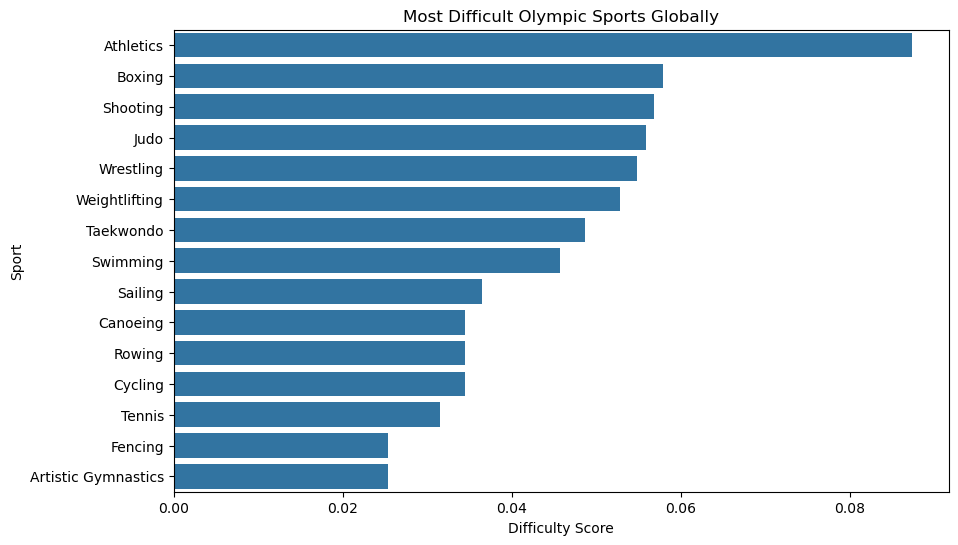

In [20]:
# =========================================
# GLOBAL SPORT DIFFICULTY VISUALIZATION
# =========================================

top_difficult = sport_competition.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_difficult,
    x="Difficulty_Score",
    y="Sport"
)

plt.title("Most Difficult Olympic Sports Globally")
plt.xlabel("Difficulty Score")
plt.ylabel("Sport")

plt.show()

In [21]:
# =========================================
# RADAR COMPARISON DATA
# =========================================

radar_sports = india_competitive_context.head(5)

radar_data = radar_sports[[
    "Sport",
    "Total_Medals",
    "Leader_Medals"
]]

print(radar_data.to_string(index=False))

    Sport  Total_Medals  Leader_Medals
   Hockey             2             11
 Shooting             7             49
Wrestling             7             50
Badminton             3             37
   Boxing             3             39


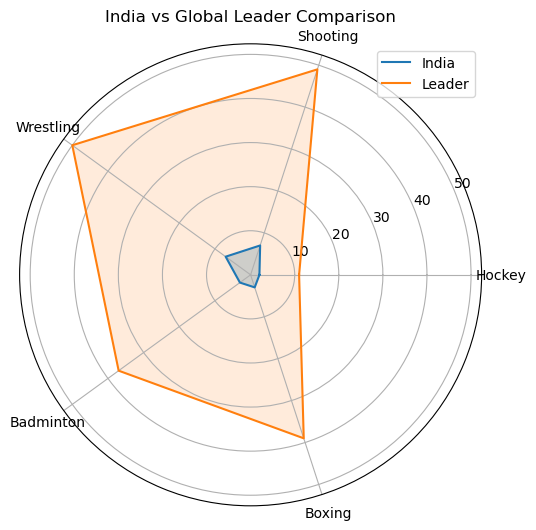

In [22]:
# =========================================
# RADAR CHART
# =========================================

import numpy as np

labels = radar_data["Sport"].values

india_values = radar_data["Total_Medals"].values
leader_values = radar_data["Leader_Medals"].values

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

india_values = np.concatenate((india_values,[india_values[0]]))
leader_values = np.concatenate((leader_values,[leader_values[0]]))
angles = np.concatenate((angles,[angles[0]]))

fig = plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

ax.plot(angles, india_values, label="India")
ax.fill(angles, india_values, alpha=0.25)

ax.plot(angles, leader_values, label="Leader")
ax.fill(angles, leader_values, alpha=0.15)

ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)

plt.title("India vs Global Leader Comparison")
plt.legend()

plt.show()

In [23]:
# =========================================
# STRATEGIC SPORT CLASSIFICATION
# =========================================

def classify(row):
    if row["Closeness_Score"] > 0.3:
        return "Strong"
    elif row["Closeness_Score"] > 0.1:
        return "Competitive"
    else:
        return "Long-Term"

india_competitive_context["Strategic_Category"] = (
    india_competitive_context.apply(classify, axis=1)
)

print("\n--- Strategic Sport Categories ---\n")
print(india_competitive_context[
    ["Sport","Closeness_Score","Strategic_Category"]
].to_string(index=False))


--- Strategic Sport Categories ---

        Sport  Closeness_Score Strategic_Category
       Hockey         0.181818        Competitive
     Shooting         0.142857        Competitive
    Wrestling         0.140000        Competitive
    Badminton         0.081081          Long-Term
       Boxing         0.076923          Long-Term
Weightlifting         0.046512          Long-Term
    Athletics         0.010870          Long-Term


In [24]:
# =========================================
# FINAL GLOBAL INTELLIGENCE TABLE
# =========================================

final_table = india_competitive_context.sort_values(
    "Closeness_Score",
    ascending=False
)

print("\n--- Final Global Intelligence Table ---\n")
print(f"Shape: {final_table.shape}")
print(f"Columns: {list(final_table.columns)}")
print()
print(final_table.to_string(index=False))


--- Final Global Intelligence Table ---

Shape: (7, 9)
Columns: ['Sport', 'NOC', 'Total_Medals', 'Rank', 'Leader_Medals', 'Gap_to_Leader', 'Competitive_Pressure_Index', 'Closeness_Score', 'Strategic_Category']

        Sport NOC  Total_Medals  Rank  Leader_Medals  Gap_to_Leader  Competitive_Pressure_Index  Closeness_Score Strategic_Category
       Hockey IND             2   5.0             11              9                    0.238095         0.181818        Competitive
     Shooting IND             7   9.0             49             42                    0.171254         0.142857        Competitive
    Wrestling IND             7  13.0             50             43                    0.117137         0.140000        Competitive
    Badminton IND             3   7.0             37             34                    0.144231         0.081081          Long-Term
       Boxing IND             3  16.0             39             36                    0.165698         0.076923          Long-T

In [25]:
# =========================================
# EXPORT ALL GLOBAL INTELLIGENCE CSVs
# =========================================

import os
os.makedirs("../data/processed", exist_ok=True)

# 1. Final global intelligence table (main output)
final_table.to_csv(
    "../data/processed/india_global_intelligence.csv", index=False)

# 2. Opportunity sports
opportunity_sports[
    ["Sport","Total_Medals","Leader_Medals","Gap_to_Leader",
     "Closeness_Score","Competitive_Pressure_Index"]
].to_csv(
    "../data/processed/india_opportunity_sports.csv", index=False)

# 3. Sport competition / difficulty
sport_competition.to_csv(
    "../data/processed/global_sport_competition.csv", index=False)

# 4. Top 5 per sport
top5_sports.to_csv(
    "../data/processed/global_top5_per_sport.csv", index=False)

# 5. Radar data
radar_data.to_csv(
    "../data/processed/india_radar_data.csv", index=False)

print("✅ All W5 CSVs exported:")
print("   → india_global_intelligence.csv    :", final_table.shape)
print("   → india_opportunity_sports.csv     :", opportunity_sports.shape)
print("   → global_sport_competition.csv     :", sport_competition.shape)
print("   → global_top5_per_sport.csv        :", top5_sports.shape)
print("   → india_radar_data.csv             :", radar_data.shape)

✅ All W5 CSVs exported:
   → india_global_intelligence.csv    : (7, 9)
   → india_opportunity_sports.csv     : (5, 8)
   → global_sport_competition.csv     : (55, 6)
   → global_top5_per_sport.csv        : (446, 4)
   → india_radar_data.csv             : (5, 3)
